In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [34]:
# called dataset
dataset=pd.read_csv('/content/PeopleDataWonosari.csv')
X=dataset.iloc[:, :1]
Y=dataset.iloc[:, 1].values
mydata=pd.DataFrame(dataset)
# called it predictions of data science
datauji=pd.read_csv('/content/PeopleDataWonosari.csv')
X_uji=datauji.iloc[:, :1]
Y

array([ 9.88, 10.  , 15.74, 20.2 ,  9.94,  9.89, 10.81, 13.54])

In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create a ColumnTransformer to apply OneHotEncoder to the first column (index 0), which is 'village'
# The remainder='passthrough' ensures other columns (if any) are kept. For X, this currently doesn't apply as it only has one column.
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), [0])], remainder='passthrough')

# Apply one-hot encoding to X
X_encoded = ct.fit_transform(X)

# Get feature names for the encoded columns. This ensures the DataFrame columns are descriptive.
feature_names = ct.named_transformers_['encoder'].get_feature_names_out(X.columns)
X = pd.DataFrame(X_encoded.toarray(), columns=feature_names)

# Display the first few rows of the encoded X to confirm the transformation
print('One-hot encoded X:')
display(X.head())

One-hot encoded X:


,village_Bangelan,village_Kebobang,village_Kluwut,village_Plandi,village_Plaosan,village_Sumberdem,village_Sumbertempur,village_Wonosari
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# Apply the same one-hot encoding transformer to X_uji using only `transform()`.
# It's crucial to use the already fitted transformer to ensure consistency with the training data.
X_uji_encoded = ct.transform(X_uji)

# Convert the sparse matrix output to a DataFrame, using the same feature names generated during fitting.
X_uji = pd.DataFrame(X_uji_encoded.toarray(), columns=feature_names)

# Display the first few rows of the encoded X_uji
print('One-hot encoded X_uji:')
display(X_uji.head())

One-hot encoded X_uji:


,village_Bangelan,village_Kebobang,village_Kluwut,village_Plandi,village_Plaosan,village_Sumberdem,village_Sumbertempur,village_Wonosari
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.1, random_state=0)
print(X_test)
print(X_uji)

   village_Bangelan  village_Kebobang  village_Kluwut  village_Plandi  \
6               0.0               0.0             0.0             0.0   

   village_Plaosan  village_Sumberdem  village_Sumbertempur  village_Wonosari  
6              0.0                0.0                   1.0               0.0  
   village_Bangelan  village_Kebobang  village_Kluwut  village_Plandi  \
0               0.0               0.0             1.0             0.0   
1               0.0               0.0             0.0             1.0   
2               0.0               0.0             0.0             0.0   
3               0.0               1.0             0.0             0.0   
4               1.0               0.0             0.0             0.0   
5               0.0               0.0             0.0             0.0   
6               0.0               0.0             0.0             0.0   
7               0.0               0.0             0.0             0.0   

   village_Plaosan  village_Sumberd

In [38]:
# Fitting to data training
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Prediction range with data test
y_pred = regressor.predict(X_uji)
print(y_pred)

[ 9.88       10.         15.74       20.2         9.94        9.89
 12.74142857 13.54      ]


In [39]:
from sklearn.metrics import r2_score

# Make predictions on the test set
y_pred_test = regressor.predict(X_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred_test)

print(f"R-squared score on the test set: {r2:.4f}")

R-squared score on the test set: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [40]:
#save range to csv file

tahunuji=np.array(X_uji)
tahun=pd.DataFrame(tahunuji)
prediksi=pd.DataFrame(y_pred)
hasil=pd.concat([tahun, prediksi],axis=1)
np.savetxt('hasil.csv',hasil, delimiter=',')
hasil

,0,1,2,3,4,5,6,7,0
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.880000
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,10.000000
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,15.740000
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20.200000
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.940000
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.890000
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.741429
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.540000


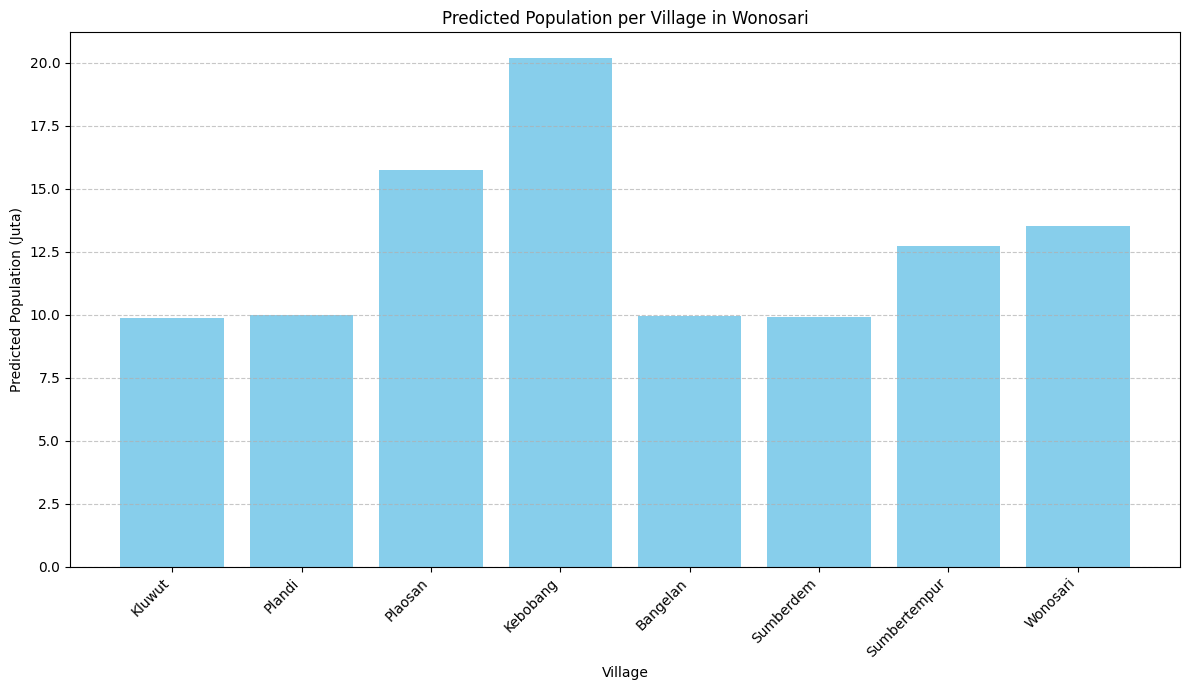

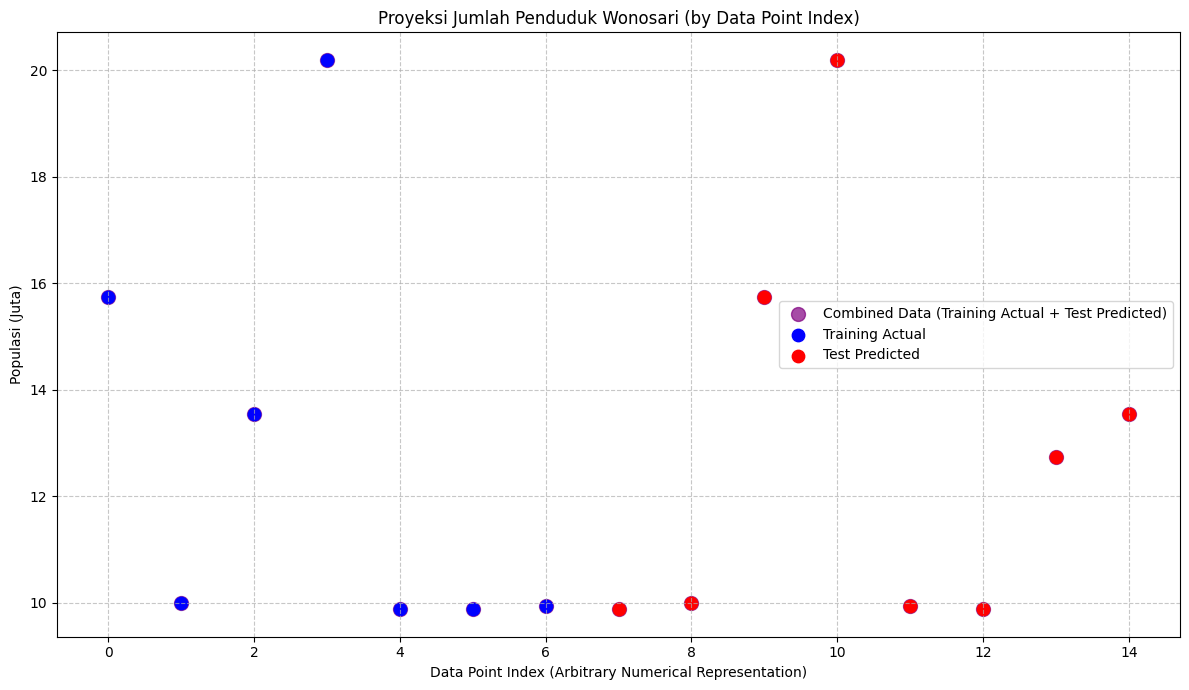

In [41]:
# data visualization

# The 'absis' variable was a 2D array of one-hot encoded features, which caused the 'x and y must be the same size' error
# when trying to plot with 'ordinat' (a 1D array). The same applied to 'tahun' and 'prediksi'.
# To visualize predicted values for categorical features like 'village', a bar chart is generally more appropriate.
# If a scatter plot with a numerical x-axis is desired, a simple index can be used, but it won't represent 'Tahun' directly.

# First, let's get the original village names for the predicted data points.
# The `datauji` DataFrame still holds the original unencoded data.
original_X_uji_villages = datauji.iloc[:len(y_pred), 0].values # Use iloc[:len(y_pred)] to match the length of y_pred

# --- Visualization 1: Bar chart for predicted population per village ---
plt.figure(figsize=(12, 7))
plt.bar(original_X_uji_villages, y_pred, color='skyblue')
plt.xlabel("Village")
plt.ylabel("Predicted Population (Juta)")
plt.title("Predicted Population per Village in Wonosari")
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualization 2: Scatter plot of all data points (train actuals + test predictions) using a numerical index ---
ordinat_combined_values = np.concatenate([y_train, y_pred])
absis_combined_data_points = np.arange(len(ordinat_combined_values))

plt.figure(figsize=(12, 7))
# Plot all combined data points
plt.scatter(absis_combined_data_points, ordinat_combined_values, label='Combined Data (Training Actual + Test Predicted)', color='purple', s=100, alpha=0.7)

# Optionally, plot training and predicted points separately for clearer distinction
train_indices = np.arange(len(y_train))
plt.scatter(train_indices, y_train, color='blue', label='Training Actual', s=80)
pred_indices = np.arange(len(y_train), len(ordinat_combined_values))
plt.scatter(pred_indices, y_pred, color='red', label='Test Predicted', s=80)


plt.xlabel("Data Point Index (Arbitrary Numerical Representation)") # Adjusted label
plt.ylabel("Populasi (Juta)")
plt.title("Proyeksi Jumlah Penduduk Wonosari (by Data Point Index)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# impor pustaka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# csv people static import
dataset=pd.read_csv('/content/PeopleDataWonosari.csv')
dataku=pd.DataFrame(dataset)
print(dataset.head())

# prepare trainer datas
# X should represent the features (e.g., village names for encoding)
X=dataset.iloc[:, :1]
# Y should represent the target variable (e.g., percentage_total_population)
Y=dataset.iloc[:,1:2].values # Corrected Y to target 'percentage_total_population'

# Apply One-Hot Encoding to X
# Create a ColumnTransformer to apply OneHotEncoder to the first column (index 0), which is 'village'
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), [0])], remainder='passthrough')

# Apply one-hot encoding to X
X_encoded = ct.fit_transform(X)

# Get feature names for the encoded columns.
feature_names = ct.named_transformers_['encoder'].get_feature_names_out(X.columns)
X_processed = pd.DataFrame(X_encoded.toarray(), columns=feature_names)

#split Data Uji with test validations
X_train, X_test, y_train, y_test = train_test_split(X_processed,Y,test_size=0.1, random_state=0)
print('pengujian untuk tahun:')
print(X_test)

# fitting
regressor = LinearRegression()
regressor.fit(X_train, y_train)

#prediction range with data testing
#prepare data will prediction
# The 'temp' variable with years was causing the dimension mismatch error.
# The model was trained on one-hot encoded village names, so X_uji must also be one-hot encoded village names.
# Let's prepare X_uji by re-encoding the village names from the original dataset for prediction.
X_uji_raw = dataset.iloc[:, :1] # Get the village column from the original dataset
X_uji = pd.DataFrame(ct.transform(X_uji_raw).toarray(), columns=feature_names) # Apply the same one-hot encoding

y_pred=regressor.predict(X_uji)
print('Hasil Prediksi = ')
print(y_pred)

    village  percentage_total_population  population_density  sex_ratio
0    Kluwut                         9.88               10.76       98.1
1    Plandi                        10.00               10.01       99.5
2   Plaosan                        15.74                8.35       98.8
3  Kebobang                        20.20                8.33      101.1
4  Bangelan                         9.94                5.75      101.7
pengujian untuk tahun:
   village_Bangelan  village_Kebobang  village_Kluwut  village_Plandi  \
6               0.0               0.0             0.0             0.0   

   village_Plaosan  village_Sumberdem  village_Sumbertempur  village_Wonosari  
6              0.0                0.0                   1.0               0.0  
Hasil Prediksi = 
[[ 9.88      ]
 [10.        ]
 [15.74      ]
 [20.2       ]
 [ 9.94      ]
 [ 9.89      ]
 [12.74142857]
 [13.54      ]]


In [43]:
# import tkinter as tk
# def prediksi():
#   """ Predicted population of the year
#   """
#   fahrenheit = ent_tahun.get()
#   X_uji = np.array(float(fahrenheit)).reshape(-1,1)
#   y_pred=regressor.predict(X_uji)
#   prediksi = float(y_pred)
#   lbl_result["text"] = f"(round(prediksi, 4)) Juta"

# # set window
# window = tk.Tk()
# window.title("Prediksi Populasi")
# window.resizable(width=False, height=False)

# #make widget for input
# #widget and label in it
# frm_entry = tk.Frame(master=window)
# ent_tahun = tk.Entry(master=frm_entry, width=10)
# lbl_tahun = tk.Label(mater=frm_entry, text="Tahun:")

# #layout form input with .grid() geometry manager
# ent_tahun.grid(row=0, column=1, sticky="e")
# lbl_tahun.grid(row=0, column=0, sticky="w")

# # create the conversion Button and result display label
# btn_convert = tk.Button(
#     master=window,
#     text="Prediksi Populasi",
#     command=prediksi
# )
# lbl_result = tk.Label(master=window, text=" Juta")

# # set up layout dgn .grid() geometry manager
# frm_entry.grid(row=0, column=1, padx=10)
# btn_convert.grid(row=0, column=2, pady=10)
# lbl_result.grid(row=0, column=3, padx=20)

# # run app
# window.mainloop()